In [4]:
!pip install torchmetrics

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try 'pacman -S
    python-xyz', where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Arch-packaged Python package,
    create a virtual environment using 'python -m venv path/to/venv'.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip.
    
    If you wish to install a non-Arch packaged Python application,
    it may be easiest to use 'pipx install xyz', which will manage a
    virtual environment for you. Make sure you have python-pipx
    installed via pacman.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detailed specification.


In [5]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchmetrics import Accuracy, Precision, Recall
from torchvision import datasets
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt

In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("gmlmrinalini/manwomandetection")

print("Path to dataset files:", path)

Path to dataset files: /home/shk/.cache/kagglehub/datasets/gmlmrinalini/manwomandetection/versions/1


In [7]:
# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [8]:
train_path = f"{path}/dataset/train"
test_path = f"{path}/dataset/test"

In [81]:
search_space = {
    "lr": [1e-4, 3e-4, 1e-3, 3e-3],
    "batch_size": [8, 16, 32],
    "dropout": [0.0, 0.3, 0.5],
    "weight_decay": [0.0, 1e-4, 1e-3]
}
import random

def sample_params(space):
    return {k: random.choice(v) for k, v in space.items()}
param = sample_params(search_space)
print("Sampled hyperparameters:", param)

Sampled hyperparameters: {'lr': 0.0003, 'batch_size': 32, 'dropout': 0.5, 'weight_decay': 0.0001}


In [114]:
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomChoice([transforms.Resize((64,64))] + [transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1)]),
    transforms.ToTensor(),
    transforms.Normalize(
    # here let's normalize deviding by 255 to scale the pixel values to [0,1]
    mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]
),
    transforms.Resize((64,64)),
])
test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((64,64)),
])

train_dataset = ImageFolder(root=train_path, transform=train_transforms)
test_dataset = ImageFolder(root=test_path, transform=test_transforms)

dataloader_train = DataLoader(train_dataset, batch_size=param['batch_size'], shuffle=True)
dataloader_test = DataLoader(test_dataset, batch_size=param['batch_size'], shuffle=False)

In [115]:
from torch.utils.data import Subset

In [116]:
random_indices = np.random.choice(len(train_dataset), size=20, replace=False)
sample_dataset = Subset(train_dataset, random_indices)
sample_dataloader = DataLoader(sample_dataset, batch_size=param['batch_size'], shuffle=False)

Feature batch shape: torch.Size([20, 3, 64, 64])
Label batch shape: torch.Size([20])


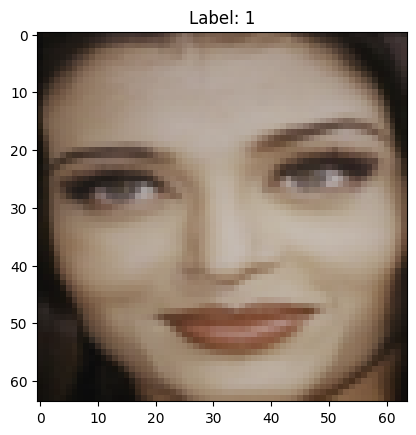

In [117]:
feature,label = next(iter(sample_dataloader))
print("Feature batch shape:", feature.shape)
print("Label batch shape:", label.shape)
plt.imshow(feature[0].permute(1, 2, 0) * 0.5 + 0.5)
plt.title(f"Label: {label[0].item()}")
plt.show()

In [118]:
import torch.nn as nn

class Net(nn.Module):
    def __init__(self):
        super().__init__()

        self.feature_extractor = nn.Sequential(
        nn.Conv2d(3, 32, 3, padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(32, 64, 3, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(64, 128, 3, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.AdaptiveAvgPool2d((1,1)),
        nn.Flatten()
    )

        self.classifier = nn.Linear(128, 1)
        self.feature_extractor.apply(self.weight_init)
        self.classifier.apply(self.weight_init)
    def weight_init(self, m):
        if isinstance(m, (nn.Conv2d, nn.Linear)):
            nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            if m.bias is not None:
                nn.init.zeros_(m.bias)

        elif isinstance(m, nn.BatchNorm2d):
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.feature_extractor(x)
        x = self.classifier(x)
        return x

In [119]:
from torch.optim.lr_scheduler import OneCycleLR

In [120]:
# Define the model
net = Net().to(device)
# Define the loss function
criterion = nn.BCEWithLogitsLoss()
# Define the optimizer
optimizer = optim.Adam(net.parameters(),lr=param['lr'],weight_decay=param['weight_decay'])

scheduler = OneCycleLR(
    optimizer, max_lr=0.01, steps_per_epoch=len(sample_dataloader), epochs=100
)

In [121]:
for epoch in range(100):
    running_loss = 0.0
    # Iterate over training batches
    for images, labels in sample_dataloader:
        labels = labels.float().unsqueeze(1)  # Reshape labels to (batch_size, 1)
        images,labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = net(images)
        loss = criterion(outputs, labels.view(outputs.shape).float())
        loss.backward()
        optimizer.step()
        scheduler.step()
        running_loss += loss.item()
    
    epoch_loss = running_loss / len(sample_dataloader)
    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")

Epoch 1, Loss: 0.5951
Epoch 2, Loss: 0.6445
Epoch 3, Loss: 0.6294
Epoch 4, Loss: 0.5758
Epoch 5, Loss: 0.4746
Epoch 6, Loss: 0.5305
Epoch 7, Loss: 0.4497
Epoch 8, Loss: 0.4821
Epoch 9, Loss: 0.4455
Epoch 10, Loss: 0.3200
Epoch 11, Loss: 0.3967
Epoch 12, Loss: 0.3729
Epoch 13, Loss: 0.3885
Epoch 14, Loss: 0.3764
Epoch 15, Loss: 0.2618
Epoch 16, Loss: 0.4360
Epoch 17, Loss: 0.3552
Epoch 18, Loss: 0.2097
Epoch 19, Loss: 0.4929
Epoch 20, Loss: 0.1884
Epoch 21, Loss: 0.1636
Epoch 22, Loss: 0.6563
Epoch 23, Loss: 0.3399
Epoch 24, Loss: 0.6421
Epoch 25, Loss: 0.1833
Epoch 26, Loss: 0.1761
Epoch 27, Loss: 0.3248
Epoch 28, Loss: 1.2624
Epoch 29, Loss: 0.3129
Epoch 30, Loss: 0.3967
Epoch 31, Loss: 0.4047
Epoch 32, Loss: 0.3971
Epoch 33, Loss: 0.3991
Epoch 34, Loss: 0.3420
Epoch 35, Loss: 0.2984
Epoch 36, Loss: 0.2935
Epoch 37, Loss: 0.2205
Epoch 38, Loss: 0.2197
Epoch 39, Loss: 0.2098
Epoch 40, Loss: 0.1970
Epoch 41, Loss: 0.1618
Epoch 42, Loss: 0.1842
Epoch 43, Loss: 0.1766
Epoch 44, Loss: 0.14

In [122]:
scheduler.get_last_lr()

[5.074647154757324e-06]

In [123]:
# Define metrics
metric_precision = Precision(task='binary', average='micro')
metric_recall = Recall(task='binary', average='micro')
acc = Accuracy(task='binary')
net.eval()
with torch.no_grad():
    for images, labels in sample_dataloader:
        images = images.to(device)
        outputs = net(images)

        preds = (torch.sigmoid(outputs) > 0.5).long().squeeze(1).cpu()

        metric_precision(preds, labels)
        metric_recall(preds, labels)
        acc(preds, labels)
precision = metric_precision.compute()
recall = metric_recall.compute()
accuracy = acc.compute()
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"Accuracy: {accuracy}")

Precision: 1.0
Recall: 1.0
Accuracy: 1.0


In [124]:
for epoch in range(20):
    running_loss = 0.0
    # Iterate over training batches
    for images, labels in dataloader_train:
        images,labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = net(images)
        loss = criterion(outputs, labels.view(outputs.shape).float())
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    epoch_loss = running_loss / len(dataloader_train)
    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")

Epoch 1, Loss: 0.9208
Epoch 2, Loss: 0.9136
Epoch 3, Loss: 0.9039


KeyboardInterrupt: 

In [ ]:
# Define metrics
metric_precision = Precision(task='binary', average='micro')
metric_recall = Recall(task='binary', average='micro')
acc = Accuracy(task='binary')
net.eval()
with torch.no_grad():
    for images, labels in dataloader_test:
        images = images.to(device)
        outputs = net(images)

        preds = (torch.sigmoid(outputs) > 0.5).long().squeeze(1).cpu()

        metric_precision(preds, labels)
        metric_recall(preds, labels)
        acc(preds, labels)
precision = metric_precision.compute()
recall = metric_recall.compute()
accuracy = acc.compute()
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"Accuracy: {accuracy}")

Precision: 0.5086705088615417
Recall: 0.5086705088615417
Accuracy: 0.5086705088615417


In [ ]:
# save model
torch.save(net.state_dict(), "man_woman_model.pth")

In [ ]:
# load model
net.load_state_dict(torch.load("man_woman_model.pth",map_location=torch.device('cpu') ))

<All keys matched successfully>

In [ ]:
# Test new data
from PIL import Image
def predict_image(image_path, model, transform):
    img = Image.open(image_path).convert('RGB')
    transform = transforms.Compose([
        transforms.Resize((64, 64)),  # must match training
        transforms.RandomCrop(64),  # must match training
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    img = transform(img).unsqueeze(0).to(device)  # shape: (1,3,64,64)

    # --- 3. Predict ---
    with torch.no_grad():
        output = model(img)
        prob = torch.sigmoid(output).item()
        pred = 1 if prob > 0.5 else 0

    # --- 4. Map to label ---
    label_map = {0: "man", 1: "woman"}

    return {
        "prediction": label_map[pred],
        "probability": prob
    }

In [ ]:
print(predict_image("image.png", net, test_transforms))
print(predict_image("image copy.png", net, test_transforms))
print(predict_image("image copy 2.png", net, test_transforms))
print(predict_image("image copy 3.png", net, test_transforms))
print(predict_image("image copy 4.png", net, test_transforms))
print(predict_image("image copy 5.png", net, test_transforms))
print(predict_image("image copy 6.png", net, test_transforms))
print(predict_image("image copy 7.png", net, test_transforms))

[W317 10:31:07.067418869 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W317 10:31:07.121808315 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W317 10:31:07.148048931 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W317 10:31:07.195196022 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W317 10:31:07.213321372 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W317 10:31:07.254116776 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W317 10:31:07.268183004 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.


{'prediction': 'man', 'probability': 2.6954384679811483e-07}
{'prediction': 'man', 'probability': 1.6380812439820147e-06}
{'prediction': 'man', 'probability': 7.594523776788265e-05}
{'prediction': 'man', 'probability': 1.7085139480753347e-18}
{'prediction': 'man', 'probability': 9.208555445949784e-11}
{'prediction': 'man', 'probability': 1.3954401937893608e-15}
{'prediction': 'man', 'probability': 1.1721351320104212e-11}
{'prediction': 'man', 'probability': 5.1247111274163324e-17}


[W317 10:31:07.312746787 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W317 10:31:07.332382026 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W317 10:31:07.389620922 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W317 10:31:07.411145323 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W317 10:31:07.470444358 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W317 10:31:07.492701938 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W317 10:31:07.494678479 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W317 10:31:07.498985763 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W317 10:31:07.501099919 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
